<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-01-02 01:53:53--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  57.1MB/s    in 3.6s    

2026-01-02 01:53:59 (55.5 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


In [10]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])

CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


Number of valid records: 32,048


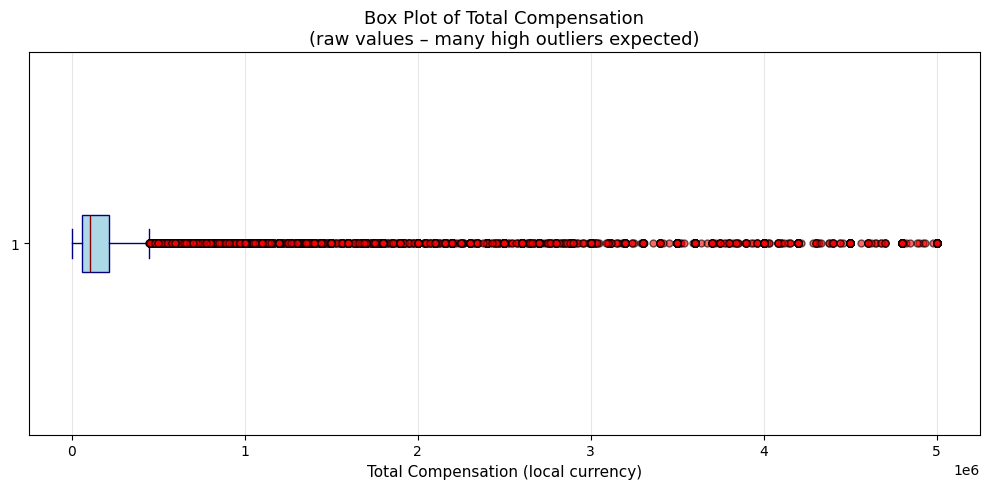


Basic statistics:
count      32048.0
mean      324200.0
std       658964.0
min         1095.0
25%        60000.0
50%       104000.0
75%       215000.0
max      5000000.0
Name: CompTotal, dtype: float64


In [30]:
# your code goes here
query = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
  AND CompTotal > 1000
  AND CompTotal <= 5000000
"""
df = pd.read_sql_query(query, conn)

print(f"Number of valid records: {len(df):,}")

plt.figure(figsize=(10, 5))

plt.boxplot(df['CompTotal'], 
            vert=False, 
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'),
            medianprops=dict(color='darkred'),
            whiskerprops=dict(color='navy'),
            capprops=dict(color='navy'),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.6))

plt.title('Box Plot of Total Compensation\n(raw values – many high outliers expected)', 
          fontsize=13)
plt.xlabel('Total Compensation (local currency)', fontsize=11)
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Statistics
print("\nBasic statistics:")
print(df['CompTotal'].describe().round(0))

Original records: 32,399
After realistic filter: 26,786 (82.7%)


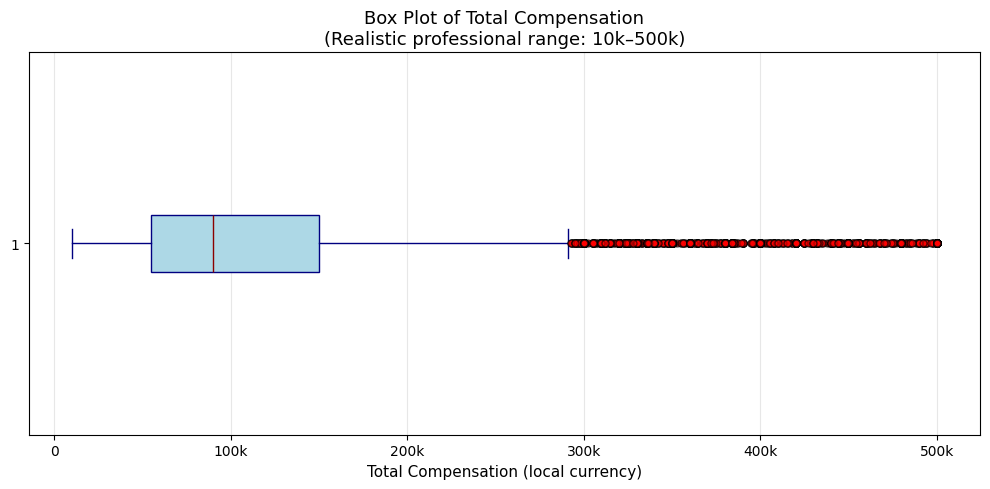

In [23]:
query = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
  AND CompTotal > 1000
  AND CompTotal <= 10000000   -- very high upper limit
"""
df = pd.read_sql_query(query, conn)

# Filtered to "realistic" professional range 
df_real = df[(df['CompTotal'] >= 10000) & (df['CompTotal'] <= 500000)]

print(f"Original records: {len(df):,}")
print(f"After realistic filter: {len(df_real):,} ({len(df_real)/len(df)*100:.1f}%)")

plt.figure(figsize=(10, 5))

plt.boxplot(df_real['CompTotal'], 
            vert=False, 
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'),
            medianprops=dict(color='darkred'),
            whiskerprops=dict(color='navy'),
            capprops=dict(color='navy'),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.6))

plt.title('Box Plot of Total Compensation\n(Realistic professional range: 10k–500k)', 
          fontsize=13)
plt.xlabel('Total Compensation (local currency)', fontsize=11)
plt.grid(True, alpha=0.3, axis='x')

# x-axis formatting (k/M)
def format_k_m(x, pos):
    if x >= 1000000:
        return f'{x/1000000:.1f}M'
    elif x >= 1000:
        return f'{x/1000:.0f}k'
    return f'{x:.0f}'

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_k_m))

plt.tight_layout()
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


Total respondents with Age: 65,115
Records after conversion: 65,115


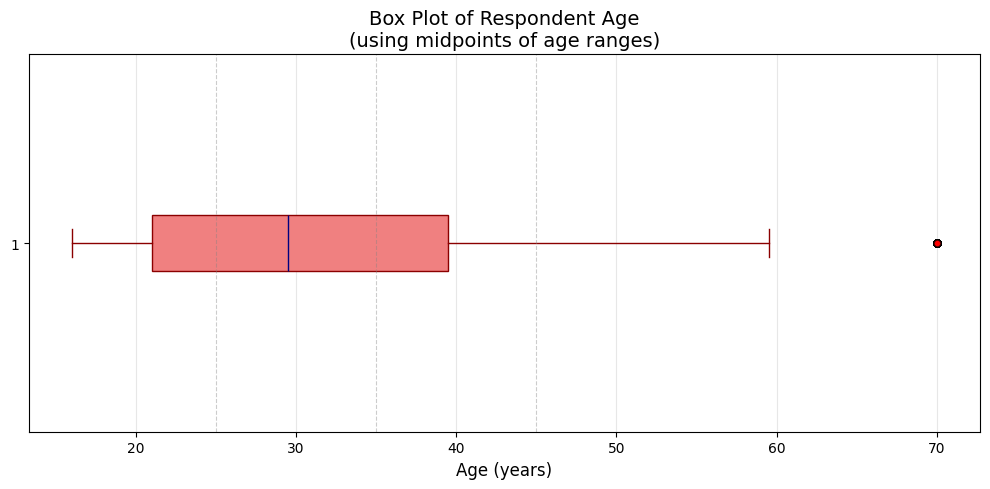


Age statistics (midpoint method):
count    65115.0
mean        33.0
std         11.3
min         16.0
25%         21.0
50%         29.5
75%         39.5
max         70.0
Name: AgeNumeric, dtype: float64


In [34]:
query = """
SELECT Age
FROM main
WHERE Age IS NOT NULL
  AND Age != 'Prefer not to say'
"""
df = pd.read_sql_query(query, conn)

print(f"Total respondents with Age: {len(df):,}")

def age_to_number_simple(age_str):
    mapping = {
        'under 18 years old': 16,
        '18-24 years old': 21,
        '25-34 years old': 29.5,
        '35-44 years old': 39.5,
        '45-54 years old': 49.5,
        '55-64 years old': 59.5,
        '65 years or older': 70
    }
    return mapping.get(str(age_str).strip().lower(), None)

df['AgeNumeric'] = df['Age'].apply(age_to_number_simple)
df_clean = df[df['AgeNumeric'].notna()]

print(f"Records after conversion: {len(df_clean):,}")

plt.figure(figsize=(10, 5))

plt.boxplot(df_clean['AgeNumeric'], 
            vert=False, 
            patch_artist=True,
            boxprops=dict(facecolor='lightcoral', color='darkred'),
            medianprops=dict(color='navy'),
            whiskerprops=dict(color='darkred'),
            capprops=dict(color='darkred'),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.6))

plt.title('Box Plot of Respondent Age\n(using midpoints of age ranges)', fontsize=14)
plt.xlabel('Age (years)', fontsize=12)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()

# Reference lines for typical age groups
for age in [25, 35, 45]:
    plt.axvline(age, color='gray', linestyle='--', alpha=0.4, lw=0.8)

plt.show()

# Statistics
print("\nAge statistics (midpoint method):")
print(df_clean['AgeNumeric'].describe().round(1))

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


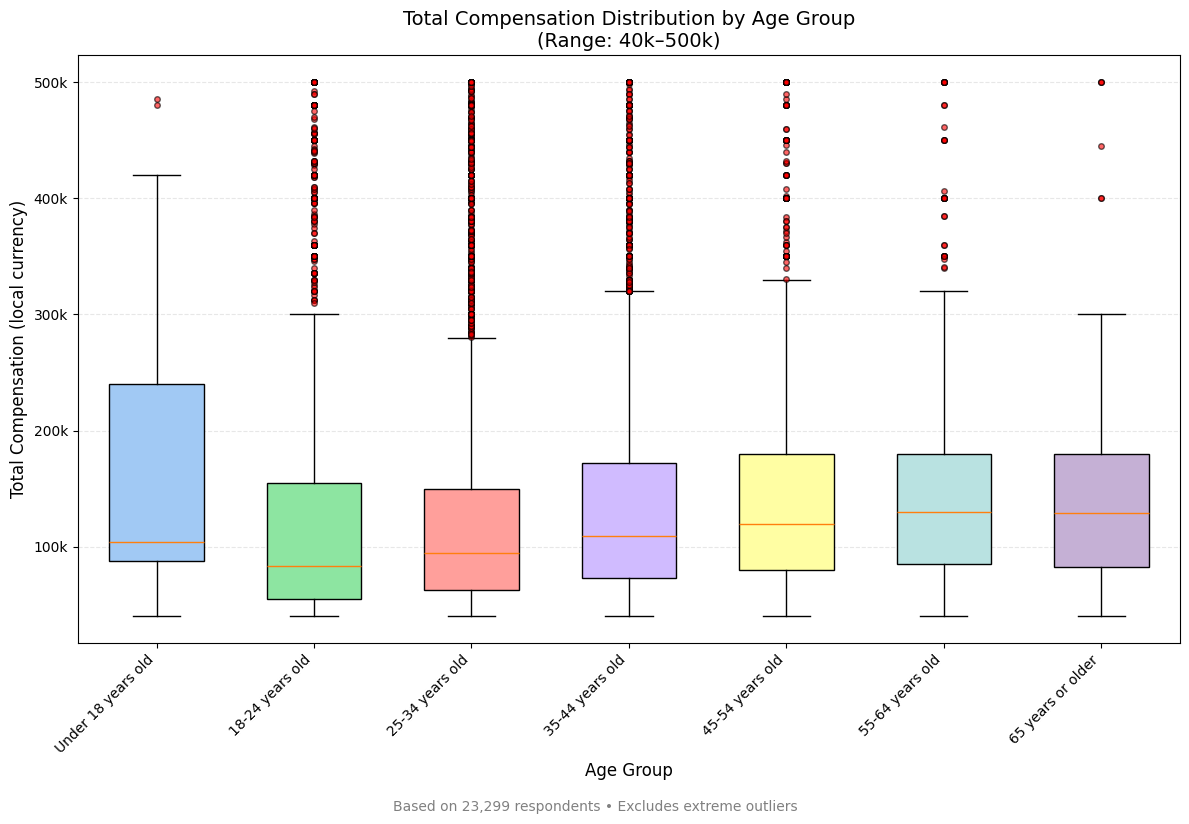

In [55]:
# your code goes here
query = """
SELECT CompTotal, Age
FROM main
WHERE CompTotal IS NOT NULL
  AND CompTotal > 1000
  AND CompTotal <= 5000000
  AND Age IS NOT NULL
  AND Age != 'Prefer not to say'
"""
df = pd.read_sql_query(query, conn)

df = df[(df['CompTotal'] >= 40000) & (df['CompTotal'] <= 500000)]

# Desired order 
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

# Filter only existing groups
age_order = [a for a in age_order if a in df['Age'].unique()]

# Group data for boxplot
data_groups = [df[df['Age'] == age]['CompTotal'] for age in age_order]

plt.figure(figsize=(12, 8))

bp = plt.boxplot(data_groups,
                 tick_labels=age_order,
                 vert=True,
                 patch_artist=True,
                 widths=0.6,
                 showfliers=True,
                 flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.6))

# Custom colors
colors = ['#a1c9f4', '#8de5a1', '#ff9f9b', '#d0bbff', '#fffea3', '#b9e2e1', '#c5b0d5']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Total Compensation Distribution by Age Group\n(Range: 40k–500k)', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Total Compensation (local currency)', fontsize=12)

# Currency formatting
def format_k_m(x, pos):
    if x >= 1000000:
        return f'{x/1000000:.1f}M'
    elif x >= 1000:
        return f'{x/1000:.0f}k'
    return f'{int(x)}'

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_k_m))

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

plt.figtext(0.5, -0.02,
            f'Based on {len(df):,} respondents • Excludes extreme outliers',
            ha='center', fontsize=10, color='gray')

plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


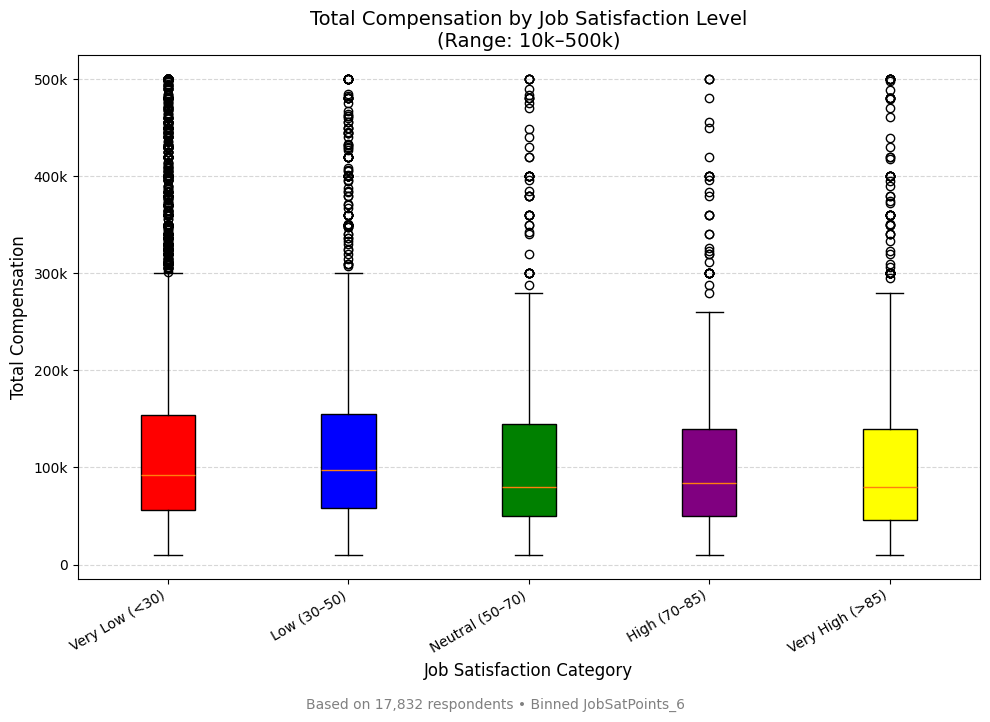

In [82]:
# your code goes here
query = """
SELECT CompTotal, JobSatPoints_6
FROM main
WHERE CompTotal IS NOT NULL
  AND CompTotal > 1000
  AND CompTotal <= 5000000
  AND JobSatPoints_6 IS NOT NULL
"""
df = pd.read_sql_query(query, conn)

df = df[(df['CompTotal'] >= 10000) & (df['CompTotal'] <= 500000)]

# Bin JobSatPoints_6 into clear categories 
bins = [-float('inf'), 30, 50, 70, 85, float('inf')]
labels = ['Very Low (<30)', 'Low (30–50)', 'Neutral (50–70)', 'High (70–85)', 'Very High (>85)']

df['SatGroup'] = pd.cut(df['JobSatPoints_6'], bins=bins, labels=labels, include_lowest=True)

# Remove any NaN groups
df = df[df['SatGroup'].notna()]

# Prepare groups in logical order
group_order = ['Very Low (<30)', 'Low (30–50)', 'Neutral (50–70)', 'High (70–85)', 'Very High (>85)']
data_groups = [df[df['SatGroup'] == g]['CompTotal'] for g in group_order]

plt.figure(figsize=(10, 7))

bp = plt.boxplot(data_groups,
                 tick_labels=group_order,
                 vert=True,
                 patch_artist=True,
                 widths=0.3)

colors = ['red', 'blue', 'green', 'purple', 'yellow']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Total Compensation by Job Satisfaction Level\n(Range: 10k–500k)', fontsize=14)
plt.xlabel('Job Satisfaction Category', fontsize=12)
plt.ylabel('Total Compensation', fontsize=12)

def format_k_m(x, pos):
    if x >= 1000000:
        return f'{x/1e6:.1f}M'
    elif x >= 1000:
        return f'{x/1e3:.0f}k'
    return f'{int(x)}'

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_k_m))
plt.grid(axis='y', alpha=0.5, linestyle='--')
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.tight_layout()

plt.figtext(0.5, -0.02, f'Based on {len(df):,} respondents • Binned JobSatPoints_6', 
            ha='center', fontsize=10, color='gray')

plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


Total valid records (ConvertedCompYearly + DevType): 22,855
Top 5 Developer Types:
 - Developer
 - full-stack
 - back-end
 - front-end
 - desktop or enterprise applications


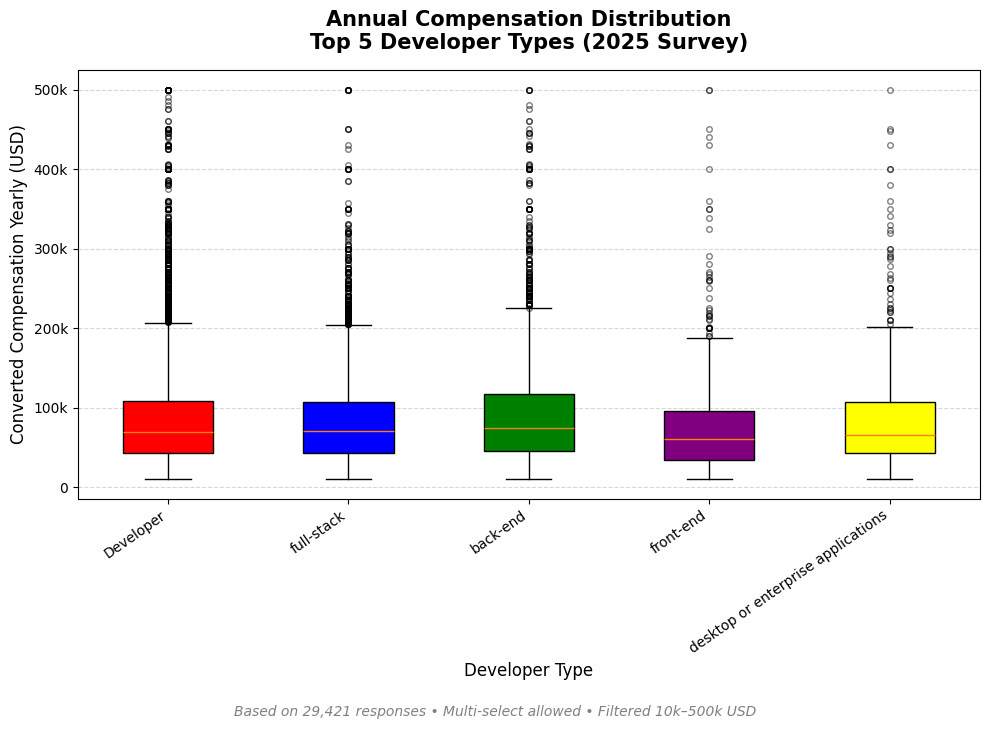


Compensation statistics for top 5 developer types:
                                    count     mean   median      min       max
DevType                                                                       
Developer                           15678  84764.0  69814.0  10000.0  500000.0
full-stack                           7347  82597.0  70000.0  10000.0  500000.0
back-end                             4258  91301.0  74110.0  10000.0  500000.0
front-end                            1162  73223.0  60711.0  10169.0  500000.0
desktop or enterprise applications    976  83362.0  65975.0  10000.0  500000.0


In [90]:
# your code goes here
query = """
SELECT ConvertedCompYearly, DevType
FROM main
WHERE ConvertedCompYearly IS NOT NULL
  AND ConvertedCompYearly > 1000
  AND ConvertedCompYearly <= 10000000  -- reasonable upper limit
  AND DevType IS NOT NULL
  AND DevType != ''
"""
df = pd.read_sql_query(query, conn)

print(f"Total valid records (ConvertedCompYearly + DevType): {len(df):,}")

# Handle multi-select DevType 
df['DevType'] = df['DevType'].str.split(r'\s*,\s*')
exploded = df.explode('DevType')
exploded['DevType'] = exploded['DevType'].str.strip()

# Get top 5 most common developer types
top_types = exploded['DevType'].value_counts().head(5).index.tolist()

print("Top 5 Developer Types:")
for t in top_types:
    print(f" - {t}")

# Filter data top 5 types
df_top = exploded[exploded['DevType'].isin(top_types)].copy()

# More realistic compensation filter
df_top = df_top[(df_top['ConvertedCompYearly'] >= 10000) & 
                (df_top['ConvertedCompYearly'] <= 500000)]

data_groups = [df_top[df_top['DevType'] == dev]['ConvertedCompYearly'] 
               for dev in top_types]

plt.figure(figsize=(10, 7))

bp = plt.boxplot(data_groups,
                 tick_labels=top_types,
                 vert=True,
                 patch_artist=True,
                 widths=0.5,
                 showfliers=True,
                 flierprops=dict(marker='o', markersize=4, alpha=0.5))

colors = ['red', 'blue', 'green', 'purple', 'yellow']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Annual Compensation Distribution\nTop 5 Developer Types (2025 Survey)', 
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Developer Type', fontsize=12)
plt.ylabel('Converted Compensation Yearly (USD)', fontsize=12)

# Currency formatting
def usd_format(x, pos):
    if x >= 1000000:
        return f'{x/1e6:.1f}M'
    elif x >= 1000:
        return f'{x/1e3:.0f}k'
    return f'{int(x)}'

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(usd_format))

plt.xticks(rotation=35, ha='right', fontsize=10)
plt.grid(axis='y', alpha=0.5, linestyle='--')
plt.tight_layout()

plt.figtext(0.5, -0.03,
            f'Based on {len(df_top):,} responses • Multi-select allowed • Filtered 10k–500k USD',
            ha='center', fontsize=10, color='gray', style='italic')

plt.show()

print("\nCompensation statistics for top 5 developer types:")
summary = df_top.groupby('DevType')['ConvertedCompYearly'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(0).reindex(top_types)
print(summary)

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


Total valid records (CompTotal + Country): 32,048
Top 5 Countries by number of respondents:
 - United States of America
 - Germany
 - United Kingdom of Great Britain and Northern Ireland
 - Ukraine
 - India


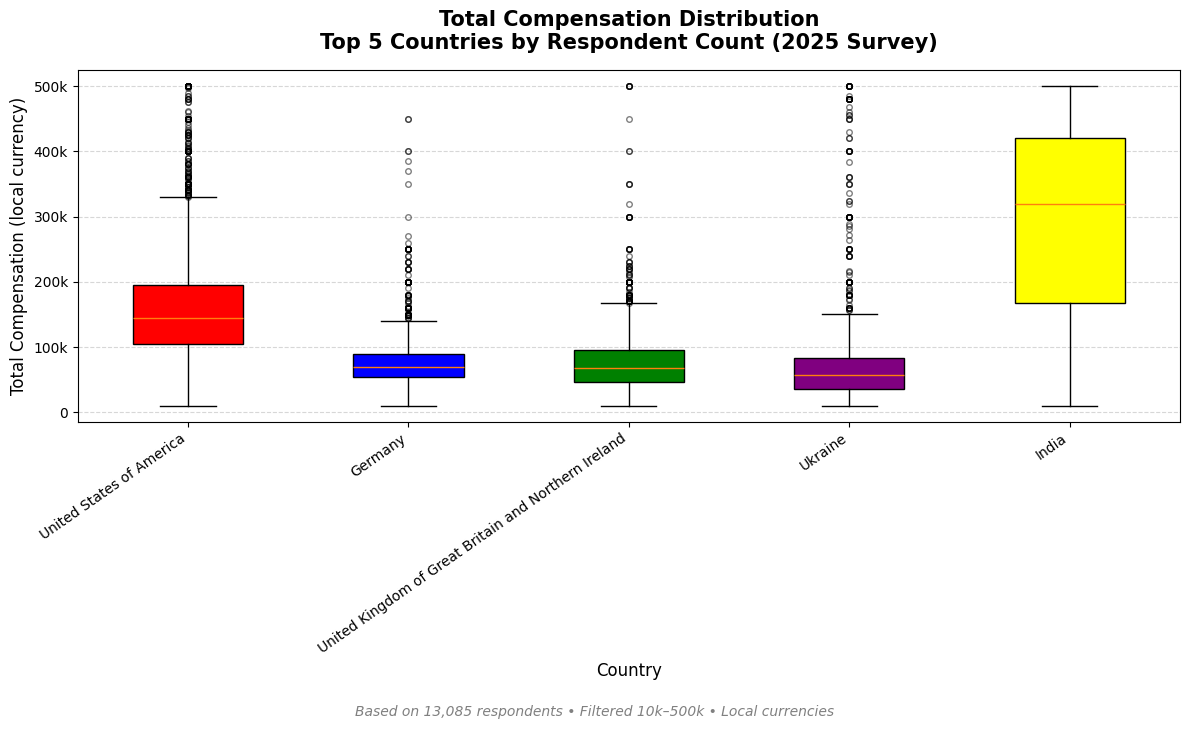


Compensation statistics for top 5 countries:
                                                    count      mean    median  \
Country                                                                         
United States of America                             6864  156981.0  145000.0   
Germany                                              2908   73836.0   70000.0   
United Kingdom of Great Britain and Northern Ir...   1988   78199.0   67916.0   
Ukraine                                               998   84233.0   58000.0   
India                                                 327  296469.0  320000.0   

                                                        min       max  
Country                                                                
United States of America                            10000.0  500000.0  
Germany                                             10000.0  450000.0  
United Kingdom of Great Britain and Northern Ir...  10000.0  500000.0  
Ukraine                   

In [93]:
# your code goes here
query = """
SELECT CompTotal, Country
FROM main
WHERE CompTotal IS NOT NULL
  AND CompTotal > 1000
  AND CompTotal <= 5000000
  AND Country IS NOT NULL
  AND Country != ''
"""
df = pd.read_sql_query(query, conn)

print(f"Total valid records (CompTotal + Country): {len(df):,}")

# Top 5 countries by number of respondents
top_countries = df['Country'].value_counts().head(5).index.tolist()

print("Top 5 Countries by number of respondents:")
for c in top_countries:
    print(f" - {c}")

# Only these top 5 countries
df_top = df[df['Country'].isin(top_countries)].copy()

df_top = df_top[(df_top['CompTotal'] >= 10000) & (df_top['CompTotal'] <= 500000)]

# Data groups in order of popularity
data_groups = [df_top[df_top['Country'] == country]['CompTotal'] 
               for country in top_countries]

plt.figure(figsize=(12, 7))

bp = plt.boxplot(data_groups,
                 tick_labels=top_countries,
                 vert=True,
                 patch_artist=True,
                 widths=0.5,
                 showfliers=True,
                 flierprops=dict(marker='o', markersize=4, alpha=0.5))

colors = ['red', 'blue', 'green', 'purple', 'yellow']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Total Compensation Distribution\nTop 5 Countries by Respondent Count (2025 Survey)', 
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Compensation (local currency)', fontsize=12)

# Currency formatting
def format_k_m(x, pos):
    if x >= 1000000:
        return f'{x/1e6:.1f}M'
    elif x >= 1000:
        return f'{x/1e3:.0f}k'
    return f'{int(x)}'

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_k_m))

plt.xticks(rotation=35, ha='right', fontsize=10)
plt.grid(axis='y', alpha=0.5, linestyle='--')
plt.tight_layout()

plt.figtext(0.5, -0.03,
            f'Based on {len(df_top):,} respondents • Filtered 10k–500k • Local currencies',
            ha='center', fontsize=10, color='gray', style='italic')

plt.show()

print("\nCompensation statistics for top 5 countries:")
summary = df_top.groupby('Country')['CompTotal'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(0).reindex(top_countries)
print(summary)

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


In [97]:
# your code goes here
print(f"Total valid records (CompTotal + Employment): {len(df):,}")

print("Employment types found (ordered by frequency):")
for et in employment_types:
    print(f" - {et} ({df['Employment'].value_counts()[et]:,} respondents)")

Total valid records (CompTotal + Employment): 32,048
Employment types found (ordered by frequency):
 - Employed, full-time (24,148 respondents)
 - Independent contractor, freelancer, or self-employed (2,323 respondents)
 - Employed, full-time;Independent contractor, freelancer, or self-employed (2,277 respondents)
 - Employed, part-time (600 respondents)
 - Employed, full-time;Student, part-time (504 respondents)
 - Employed, full-time;Student, full-time (458 respondents)
 - Student, full-time;Employed, part-time (435 respondents)
 - Student, part-time;Employed, part-time (289 respondents)
 - Independent contractor, freelancer, or self-employed;Employed, part-time (213 respondents)
 - Employed, full-time;Employed, part-time (129 respondents)
 - Not employed, but looking for work;Independent contractor, freelancer, or self-employed (104 respondents)
 - Employed, full-time;Independent contractor, freelancer, or self-employed;Student, part-time (85 respondents)
 - Employed, full-time;Inde

Records after filtering: 26,786
Groups used (min 10 respondents):
EmploymentGroup
Full-time only                             20341
Freelancer / Contractor / Self-employed     2398
Full-time + Freelance/Contractor            2064
Full-time + Student                          845
Part-time + Student                          585
Part-time only                               551
Name: count, dtype: int64


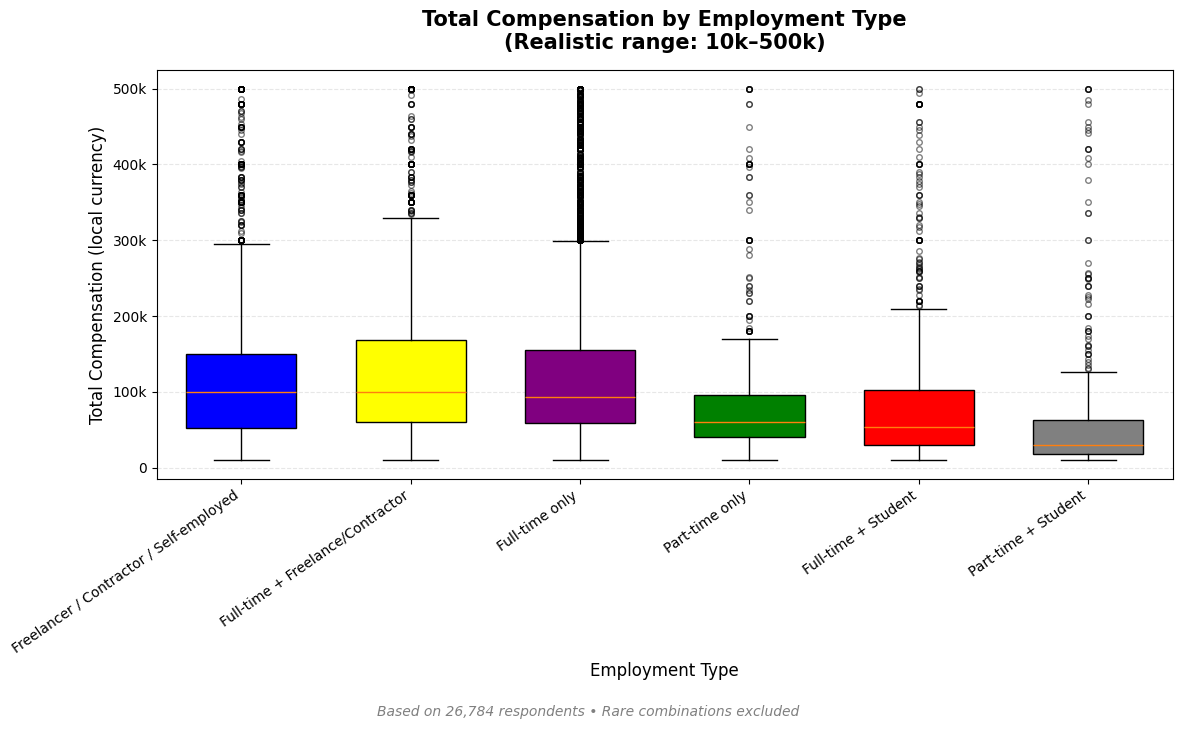


Compensation statistics by Employment Group (ordered by median):
                                         count      mean    median      min  \
EmploymentGroup                                                               
Freelancer / Contractor / Self-employed   2398  125519.0  100000.0  10000.0   
Full-time + Freelance/Contractor          2064  128750.0  100000.0  10000.0   
Full-time only                           20341  122184.0   94000.0  10000.0   
Part-time only                             551   87665.0   60000.0  10000.0   
Full-time + Student                        845   88867.0   54000.0  10000.0   
Part-time + Student                        585   60374.0   30000.0  10000.0   

                                              max  
EmploymentGroup                                    
Freelancer / Contractor / Self-employed  500000.0  
Full-time + Freelance/Contractor         500000.0  
Full-time only                           500000.0  
Part-time only                           

In [104]:
query = """
SELECT CompTotal, Employment
FROM main
WHERE CompTotal IS NOT NULL
  AND CompTotal > 1000
  AND CompTotal <= 5000000
  AND Employment IS NOT NULL
  AND Employment != ''
"""
df = pd.read_sql_query(query, conn)

# Realistic filter
df = df[(df['CompTotal'] >= 10000) & (df['CompTotal'] <= 500000)]

print(f"Records after filtering: {len(df):,}")

# Mapping / Grouping of employment types 
def simplify_employment(emp):
    emp = str(emp).lower().strip()
    if 'employed, full-time' in emp:
        if 'independent contractor' in emp or 'freelancer' in emp or 'self-employed' in emp:
            return 'Full-time + Freelance/Contractor'
        if 'student' in emp:
            return 'Full-time + Student'
        return 'Full-time only'
    if 'independent contractor' in emp or 'freelancer' in emp or 'self-employed' in emp:
        return 'Freelancer / Contractor / Self-employed'
    if 'employed, part-time' in emp:
        if 'student' in emp:
            return 'Part-time + Student'
        return 'Part-time only'
    if 'student' in emp:
        return 'Student (full or part-time)'
    if 'not employed' in emp:
        return 'Not employed / Looking for work'
    return 'Other / Rare combination'

# Apply grouping
df['EmploymentGroup'] = df['Employment'].apply(simplify_employment)

# Keep only groups with enough data
min_count = 10 
group_counts = df['EmploymentGroup'].value_counts()
valid_groups = group_counts[group_counts >= min_count].index.tolist()

df_grouped = df[df['EmploymentGroup'].isin(valid_groups)].copy()

print(f"Groups used (min {min_count} respondents):")
print(group_counts[valid_groups])

# Order by median compensation 
group_order = (
    df_grouped.groupby('EmploymentGroup')['CompTotal']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Prepare data for boxplot
data_groups = [df_grouped[df_grouped['EmploymentGroup'] == g]['CompTotal'] 
               for g in group_order]

plt.figure(figsize=(12, 7))

bp = plt.boxplot(data_groups,
                 tick_labels=group_order,
                 vert=True,
                 patch_artist=True,
                 widths=0.65,
                 showfliers=True,
                 flierprops=dict(marker='o', markersize=4, alpha=0.5))


colors = ['blue', 'yellow', 'purple', 'green', 'red', 'grey', 'brown']
colors = colors[:len(group_order)]

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Total Compensation by Employment Type\n(Realistic range: 10k–500k)', 
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Employment Type', fontsize=12)
plt.ylabel('Total Compensation (local currency)', fontsize=12)

# Currency formatting
def format_k_m(x, pos):
    if x >= 1000000:
        return f'{x/1e6:.1f}M'
    elif x >= 1000:
        return f'{x/1e3:.0f}k'
    return f'{int(x)}'

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_k_m))

plt.xticks(rotation=35, ha='right', fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

plt.figtext(0.5, -0.03,
            f'Based on {len(df_grouped):,} respondents • Rare combinations excluded',
            ha='center', fontsize=10, color='gray', style='italic')

plt.show()

print("\nCompensation statistics by Employment Group (ordered by median):")
summary = df_grouped.groupby('EmploymentGroup')['CompTotal'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(0).reindex(group_order)
print(summary)

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


Total records with both values: 28,619
Valid numeric YearsCodePro records: 28,619


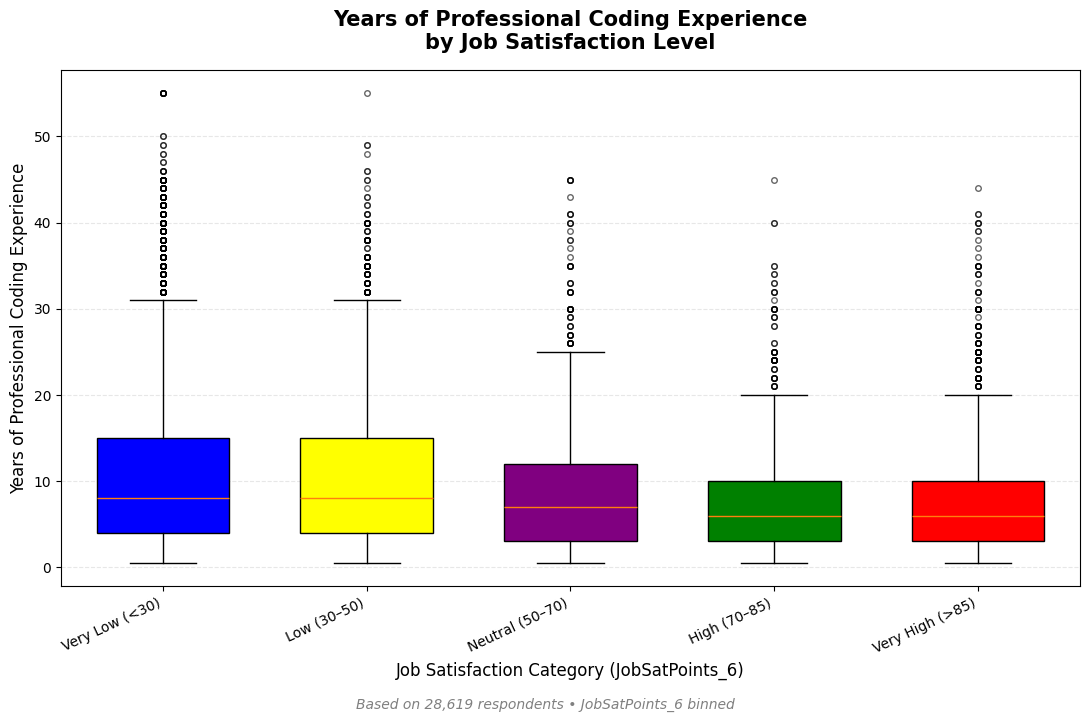


Years of experience statistics by satisfaction group:
                 count  mean  median  min   max
SatGroup                                       
Very Low (<30)   21966  10.6     8.0  0.5  55.0
Low (30–50)       2764  10.8     8.0  0.5  55.0
Neutral (50–70)   1152   9.0     7.0  0.5  45.0
High (70–85)       952   7.9     6.0  0.5  45.0
Very High (>85)   1785   7.8     6.0  0.5  44.0


/tmp/ipykernel_3847/318162570.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby('SatGroup')['YearsNumeric'].agg(


In [111]:
# your code goes here
query = """
SELECT YearsCodePro, JobSatPoints_6
FROM main
WHERE YearsCodePro IS NOT NULL
  AND JobSatPoints_6 IS NOT NULL
"""
df = pd.read_sql_query(query, conn)

print(f"Total records with both values: {len(df):,}")

# YearsCodePro to numeric 
def clean_years(x):
    x = str(x).strip().lower()
    if 'less than 1' in x or 'i have never' in x:
        return 0.5
    if 'more than 50' in x:
        return 55
    try:
        # Take first number from ranges like "5-10 years"
        import re
        nums = re.findall(r'\d+\.?\d*', x)
        if nums:
            return float(nums[0])
        return float(x)
    except:
        return None

df['YearsNumeric'] = df['YearsCodePro'].apply(clean_years)
df = df[df['YearsNumeric'].notna()]

print(f"Valid numeric YearsCodePro records: {len(df):,}")

# Bin JobSatPoints_6 categories
bins = [-float('inf'), 30, 50, 70, 85, float('inf')]
labels = ['Very Low (<30)', 'Low (30–50)', 'Neutral (50–70)', 
          'High (70–85)', 'Very High (>85)']

df['SatGroup'] = pd.cut(df['JobSatPoints_6'], 
                        bins=bins, 
                        labels=labels, 
                        include_lowest=True)

df = df[df['SatGroup'].notna()]

# Groups in logical order 
group_order = ['Very Low (<30)', 'Low (30–50)', 'Neutral (50–70)', 
               'High (70–85)', 'Very High (>85)']

data_groups = [df[df['SatGroup'] == g]['YearsNumeric'] for g in group_order]

plt.figure(figsize=(11, 7))

bp = plt.boxplot(data_groups,
                 tick_labels=group_order,
                 vert=True,
                 patch_artist=True,
                 widths=0.65,
                 showfliers=True,
                 flierprops=dict(marker='o', markersize=4, alpha=0.6))

colors = ['blue', 'yellow', 'purple', 'green', 'red']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Years of Professional Coding Experience\nby Job Satisfaction Level', 
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Job Satisfaction Category (JobSatPoints_6)', fontsize=12)
plt.ylabel('Years of Professional Coding Experience', fontsize=12)

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.tight_layout()

plt.figtext(0.5, -0.02,
            f'Based on {len(df):,} respondents • JobSatPoints_6 binned',
            ha='center', fontsize=10, color='gray', style='italic')

plt.show()

print("\nYears of experience statistics by satisfaction group:")
summary = df.groupby('SatGroup')['YearsNumeric'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(1)
print(summary)

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [ ]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
